In [218]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving XAU_1d_data.csv to XAU_1d_data.csv


In [219]:
df = pd.read_csv('XAU_1d_data.csv', sep=';')
df['Date'] = pd.to_datetime(df['Date'], format='%Y.%m.%d %H:%M')
df = df.set_index('Date')

print("DataFrame loaded successfully. First 5 rows:")
display(df.head())

DataFrame loaded successfully. First 5 rows:


,Open,High,Low,Close,Volume
Date,,,,,
2004-06-11,384.0,384.8,382.8,384.1,272
2004-06-14,384.3,385.8,381.8,382.8,1902
2004-06-15,382.8,388.8,381.1,388.6,1951
2004-06-16,387.1,389.8,382.6,383.8,2014
2004-06-17,383.6,389.3,383.0,387.6,1568


In [245]:
cols = ['Open','High','Low','Close','Volume']
df[cols] = df[cols].apply(pd.to_numeric)
df.isnull().sum()
df = df.drop_duplicates()

Testing Outlier






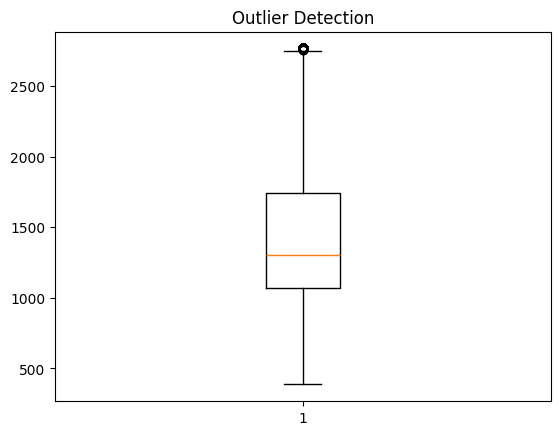

In [246]:
plt.boxplot(df['Close'])
plt.title("Outlier Detection")
plt.show()

Remove outlier (Capping) for Time Series

In [247]:
cols = ['Open','High','Low','Close']

for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)

Feature Engineering

In [248]:
# Moving averages
df['MA_7'] = df['Close'].rolling(7).mean()
df['MA_30'] = df['Close'].rolling(30).mean()

# Exponential moving average
df['EMA_7'] = df['Close'].ewm(span=7, adjust=False).mean()

# Lag features
df['Lag_1'] = df['Close'].shift(1)
df['Lag_2'] = df['Close'].shift(2)
df['Lag_3'] = df['Close'].shift(3)
df['Lag_7'] = df['Close'].shift(7)

# Returns
df['Return'] = df['Close'].pct_change()

# Rolling statistics
df['Rolling_STD_7'] = df['Close'].rolling(7).std()
df['Rolling_Max_7'] = df['Close'].rolling(7).max()
df['Rolling_Min_7'] = df['Close'].rolling(7).min()

# Volatility
df['Volatility'] = df['High'] - df['Low']
df = df.dropna()

Train–Test Split(80% – 20%)

In [249]:

features = ['Lag_1','Lag_2','Lag_3','MA_7','MA_30','Volatility']
X = df[features]
y = df['Close']
train_size = int(len(df) * 0.8)

X_train = X.iloc[:train_size]
X_test  = X.iloc[train_size:]

y_train = y.iloc[:train_size]
y_test  = y.iloc[train_size:]

print("Total Data:", len(df))
print("Training Data (First 80%):", len(X_train))
print("Testing Data (Last 20%):", len(X_test))

Total Data: 5458
Training Data (First 80%): 4366
Testing Data (Last 20%): 1092


### Scaling

In [250]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Scale y_train and y_test
y_train_scaled = scaler.fit_transform(y_train.values.reshape(-1, 1))
y_test_scaled = scaler.transform(y_test.values.reshape(-1, 1))

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)
print("y_train_scaled shape:", y_train_scaled.shape)
print("y_test_scaled shape:", y_test_scaled.shape)

X_train_scaled shape: (4366, 6)
X_test_scaled shape: (1092, 6)
y_train_scaled shape: (4366, 1)
y_test_scaled shape: (1092, 1)


### Model Training

In [251]:
from sklearn.linear_model import LinearRegression


model = LinearRegression()


model.fit(X_train_scaled, y_train_scaled)

print("Model trained successfully.")

Model trained successfully.


### LSTM Model Preparation and Training(Long Short-Term Memory)

In [252]:

X_train_lstm = X_train_scaled.reshape((X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
X_test_lstm = X_test_scaled.reshape((X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))

print(f"Reverted LSTM input shape: {X_train_lstm.shape}")

Reverted LSTM input shape: (4366, 1, 6)


In [253]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

# Reshape input to be 3D
X_train_lstm = X_train_scaled.reshape((X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
X_test_lstm = X_test_scaled.reshape((X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))

#  prevent overfitting
lstm_model = Sequential([
    Input(shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])),
    LSTM(64, activation='relu', return_sequences=True),
    Dropout(0.3),
    LSTM(32, activation='relu'),
    Dropout(0.3),
    Dense(1)
])

lstm_model.compile(optimizer='adam', loss='mse')


early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model
history = lstm_model.fit(
    X_train_lstm, y_train_scaled,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

print("LSTM model with Overfitting protections trained successfully.")

Epoch 1/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 0.3973 - val_loss: 0.0295
Epoch 2/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0571 - val_loss: 0.0179
Epoch 3/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0496 - val_loss: 0.0205
Epoch 4/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0485 - val_loss: 0.0115
Epoch 5/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0448 - val_loss: 0.0129
Epoch 6/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0406 - val_loss: 0.0097
Epoch 7/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0408 - val_loss: 0.0103
Epoch 8/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0409 - val_loss: 0.0093
Epoch 9/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0364 - val_loss: 0.0125
Epoch 10/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0387 - val_loss: 0.0066
Epoch 11/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0390 - val_loss: 0.0085
Epoch 12/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step

### XGBoost Model Training

In [254]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error

xgb_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    early_stopping_rounds=10,
    eval_metric='rmse'
)

# Train the model
xgb_model.fit(
    X_train_scaled, y_train_scaled,
    eval_set=[(X_test_scaled, y_test_scaled)],
    verbose=False
)

# Predict on test set
xgb_val_scaled = xgb_model.predict(X_test_scaled)
xgb_predictions = scaler.inverse_transform(xgb_val_scaled.reshape(-1, 1))

print(f"XGBoost model retrained successfully. Best iteration: {xgb_model.best_iteration}")

XGBoost model retrained successfully. Best iteration: 139


In [256]:
df = df.drop_duplicates()

prediction comparison

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Lengths: Actual=1069, LR=1069, LSTM=1069, Prophet=1069

--- Aligned Model Comparison (MSE) ---
Linear Regression MSE: 281.5099
LSTM MSE:              11,605.4863
Prophet MSE:           326.1562


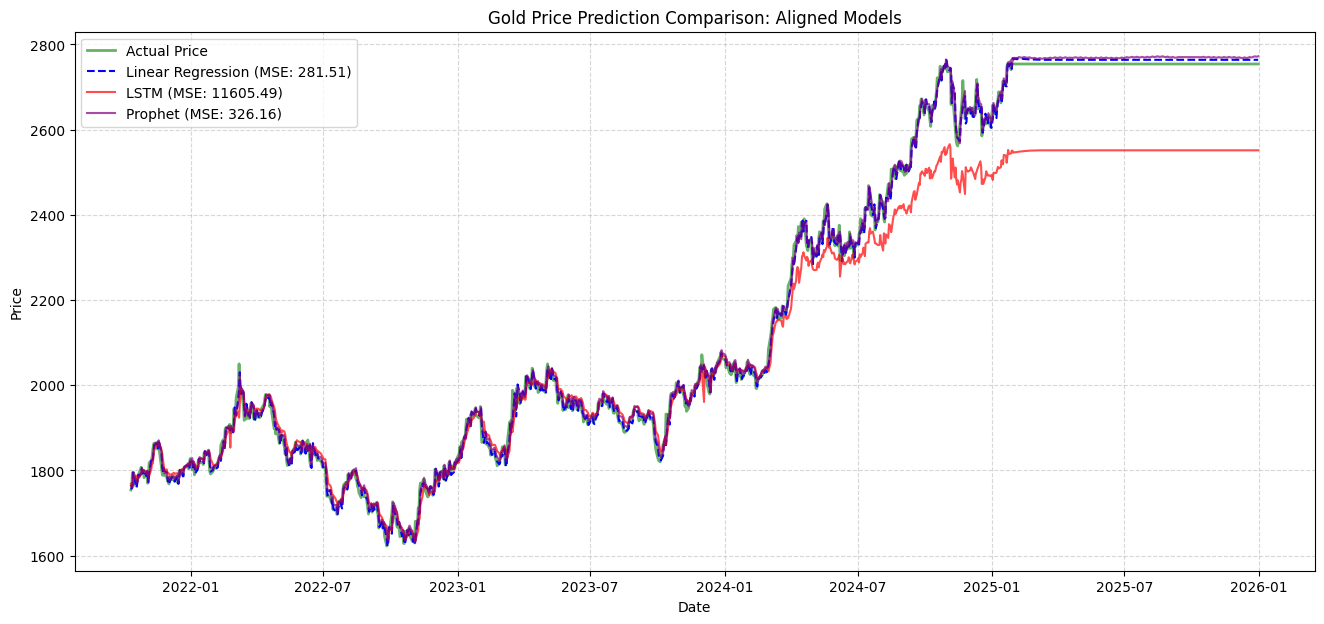

In [257]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
import numpy as np


common_index = test_prophet['ds'].tail(1069)
y_test_aligned = y_test.loc[y_test.index.isin(common_index)]


num_samples = len(y_test_aligned)
lr_preds_aligned = predictions[-num_samples:].flatten()

lm_val_scaled = lstm_model.predict(X_test_lstm)
lstm_preds_full = scaler.inverse_transform(lm_val_scaled)
lstm_preds_aligned = lstm_preds_full[-num_samples:].flatten()

# 4. Prophet predictions alignment
prophet_preds_aligned = prophet_predictions[-num_samples:]

print(f"Lengths: Actual={len(y_test_aligned)}, LR={len(lr_preds_aligned)}, LSTM={len(lstm_preds_aligned)}, Prophet={len(prophet_preds_aligned)}")


lr_mse = mean_squared_error(y_test_aligned, lr_preds_aligned)
lstm_mse = mean_squared_error(y_test_aligned, lstm_preds_aligned)
prophet_mse = mean_squared_error(y_test_aligned, prophet_preds_aligned)

print("\n--- Aligned Model Comparison (MSE) ---")
print(f"Linear Regression MSE: {lr_mse:,.4f}")
print(f"LSTM MSE:              {lstm_mse:,.4f}")
print(f"Prophet MSE:           {prophet_mse:,.4f}")


plt.figure(figsize=(16, 7))
plt.plot(y_test_aligned.index, y_test_aligned.values, label='Actual Price', color='green', linewidth=2, alpha=0.6)
plt.plot(y_test_aligned.index, lr_preds_aligned, label=f'Linear Regression (MSE: {lr_mse:.2f})', color='blue', linestyle='--')
plt.plot(y_test_aligned.index, lstm_preds_aligned, label=f'LSTM (MSE: {lstm_mse:.2f})', color='red', alpha=0.7)
plt.plot(y_test_aligned.index, prophet_preds_aligned, label=f'Prophet (MSE: {prophet_mse:.2f})', color='purple', alpha=0.7)

plt.title('Gold Price Prediction Comparison: Aligned Models')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

--- Aligned Model Comparison (MAE for last 1069 days) ---
Linear Regression MAE: 11.1151
Prophet MAE:           12.4698
LSTM MAE:              27.8142
XGBoost MAE:           287.7859


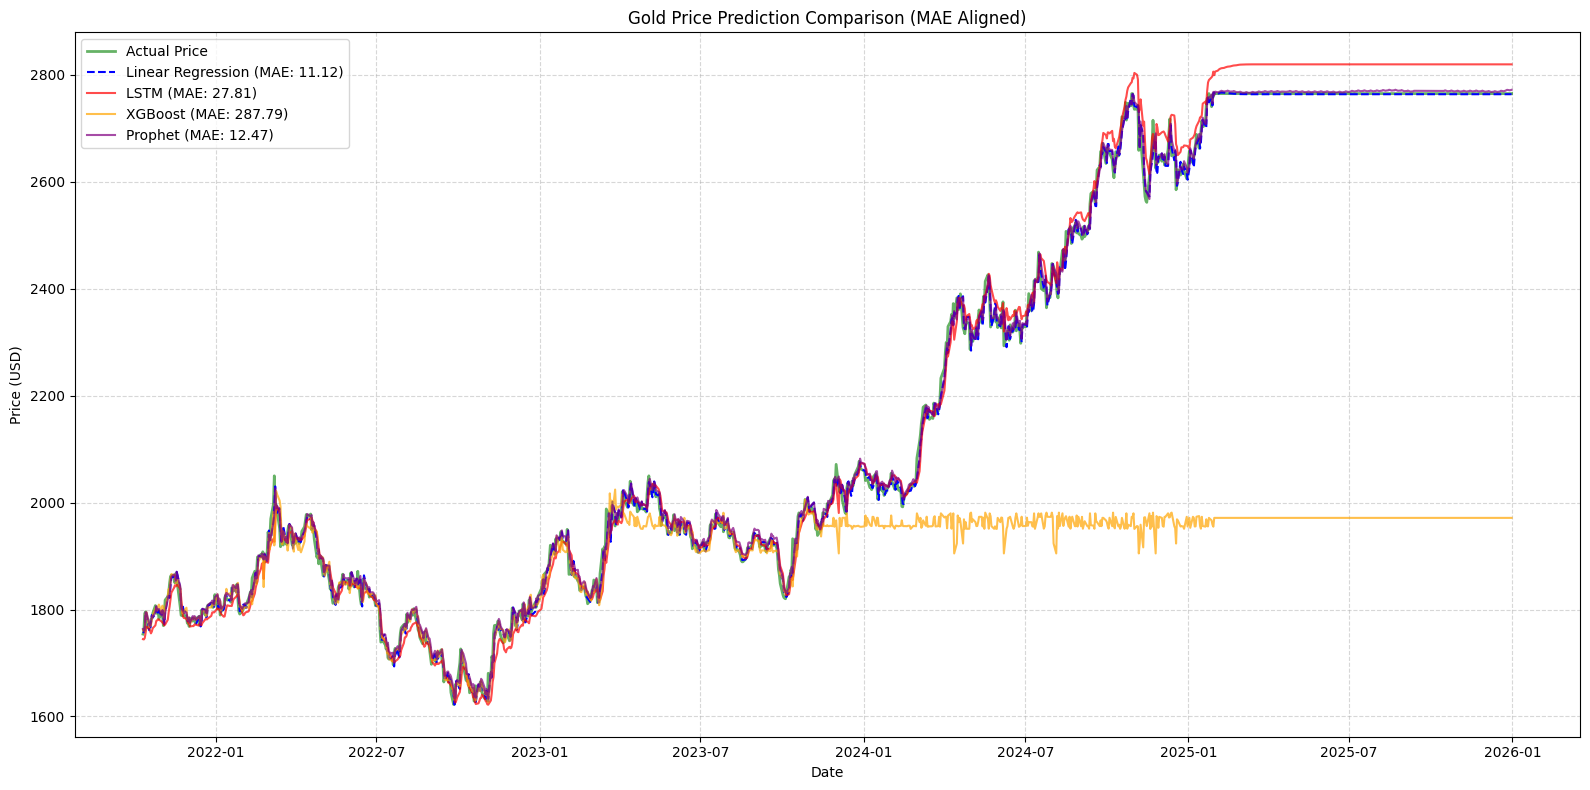

In [233]:
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt
import numpy as np


num_samples = 1069
y_test_aligned = y_test.tail(num_samples)


lr_preds_aligned = predictions[-num_samples:].flatten()
lstm_preds_aligned = lstm_preds_full[-num_samples:].flatten()
xgb_preds_aligned = xgb_predictions[-num_samples:].flatten()
prophet_preds_aligned = prophet_predictions[-num_samples:].flatten()


lr_mae = mean_absolute_error(y_test_aligned, lr_preds_aligned)
lstm_mae = mean_absolute_error(y_test_aligned, lstm_preds_aligned)
xgb_mae = mean_absolute_error(y_test_aligned, xgb_preds_aligned)
prophet_mae = mean_absolute_error(y_test_aligned, prophet_preds_aligned)

print(f"--- Aligned Model Comparison (MAE for last {num_samples} days) ---")
print(f"Linear Regression MAE: {lr_mae:,.4f}")
print(f"Prophet MAE:           {prophet_mae:,.4f}")
print(f"LSTM MAE:              {lstm_mae:,.4f}")
print(f"XGBoost MAE:           {xgb_mae:,.4f}")


plt.figure(figsize=(16, 8))
plt.plot(y_test_aligned.index, y_test_aligned.values, label='Actual Price', color='green', linewidth=2, alpha=0.6)
plt.plot(y_test_aligned.index, lr_preds_aligned, label=f'Linear Regression (MAE: {lr_mae:.2f})', color='blue', linestyle='--')
plt.plot(y_test_aligned.index, lstm_preds_aligned, label=f'LSTM (MAE: {lstm_mae:.2f})', color='red', alpha=0.7)
plt.plot(y_test_aligned.index, xgb_preds_aligned, label=f'XGBoost (MAE: {xgb_mae:.2f})', color='orange', alpha=0.7)
plt.plot(y_test_aligned.index, prophet_preds_aligned, label=f'Prophet (MAE: {prophet_mae:.2f})', color='purple', alpha=0.7)

plt.title('Gold Price Prediction Comparison (MAE Aligned)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

--- Model Comparison (R&sup2; Score) ---
Linear Regression R&sup2;: 0.9983
Prophet R&sup2;:           0.9982
LSTM R&sup2;:              0.9922


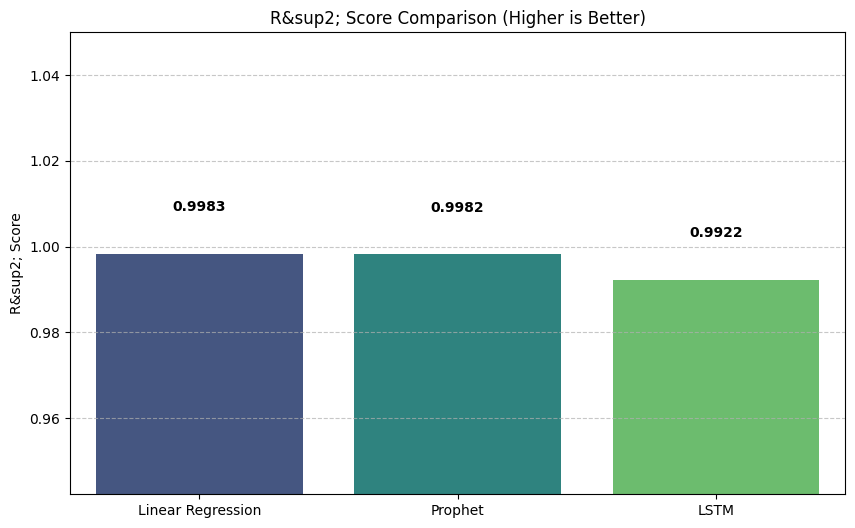

In [234]:
import seaborn as sns
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt


num_samples = 1069
y_test_aligned = y_test.tail(num_samples)


lr_preds_aligned = predictions[-num_samples:].flatten()
lstm_preds_aligned = lstm_preds_full[-num_samples:].flatten()
prophet_preds_aligned = prophet_predictions[-num_samples:].flatten()


lr_r2 = r2_score(y_test_aligned, lr_preds_aligned)
lstm_r2 = r2_score(y_test_aligned, lstm_preds_aligned)
prophet_r2 = r2_score(y_test_aligned, prophet_preds_aligned)

print("--- Model Comparison (R&sup2; Score) ---")
print(f"Linear Regression R&sup2;: {lr_r2:.4f}")
print(f"Prophet R&sup2;:           {prophet_r2:.4f}")
print(f"LSTM R&sup2;:              {lstm_r2:.4f}")


models = ['Linear Regression', 'Prophet', 'LSTM']
r2_scores = [lr_r2, prophet_r2, lstm_r2]

plt.figure(figsize=(10, 6))
sns.barplot(x=models, y=r2_scores, hue=models, palette='viridis', legend=False)

plt.title(' Score Comparison (Higher is Better)')
plt.ylabel('R&sup2; Score')
plt.ylim(min(r2_scores) - 0.05, 1.05)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for i, val in enumerate(r2_scores):
    plt.text(i, val + 0.01, f'{val:.4f}', ha='center', fontweight='bold')

plt.show()

--- Aligned Model Comparison (MAPE) ---
Linear Regression MAPE: 0.54%
Prophet MAPE:           0.60%
LSTM MAPE:              1.21%


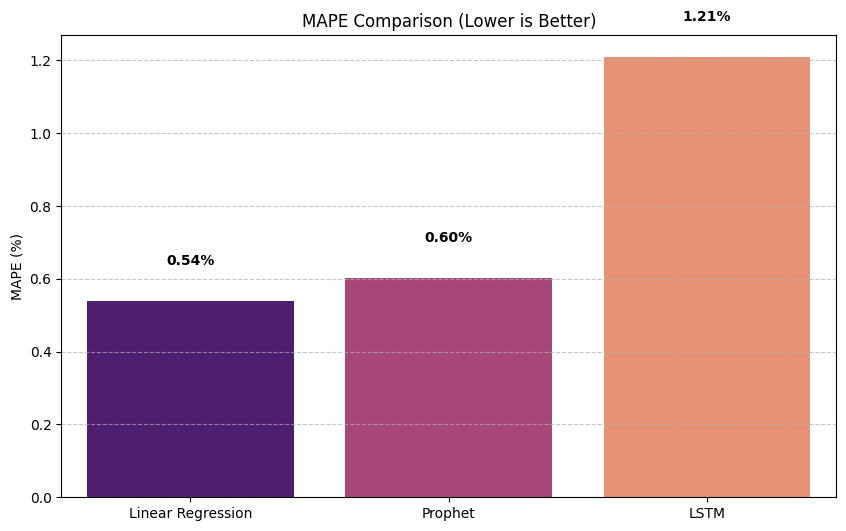

In [235]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100


num_samples = 1069
y_test_aligned_vals = y_test.tail(num_samples).values.flatten()


lr_preds_aligned = predictions[-num_samples:].flatten()
lstm_preds_aligned = lstm_preds_full[-num_samples:].flatten()
prophet_preds_aligned = prophet_predictions[-num_samples:].flatten()


lr_mape = mape(y_test_aligned_vals, lr_preds_aligned)
lstm_mape = mape(y_test_aligned_vals, lstm_preds_aligned)
prophet_mape_val = mape(y_test_aligned_vals, prophet_preds_aligned)

print("--- Aligned Model Comparison (MAPE) ---")
print(f"Linear Regression MAPE: {lr_mape:.2f}%")
print(f"Prophet MAPE:           {prophet_mape_val:.2f}%")
print(f"LSTM MAPE:              {lstm_mape:.2f}%")


plt.figure(figsize=(10, 6))
models = ['Linear Regression', 'Prophet', 'LSTM']
mapes = [lr_mape, prophet_mape_val, lstm_mape]

sns.barplot(x=models, y=mapes, hue=models, palette='magma', legend=False)
plt.title('MAPE Comparison (Lower is Better)')
plt.ylabel('MAPE (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

for i, val in enumerate(mapes):
    plt.text(i, val + 0.1, f'{val:.2f}%', ha='center', fontweight='bold')

plt.show()

### Random Forest Model Training

In [236]:
from sklearn.ensemble import RandomForestRegressor


rf_model = RandomForestRegressor(n_estimators=100, random_state=42)


rf_model.fit(X_train_scaled, y_train_scaled.ravel())


rf_val_scaled = rf_model.predict(X_test_scaled)
rf_predictions = scaler.inverse_transform(rf_val_scaled.reshape(-1, 1))

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


--- Model: Random Forest ---
MSE:  167,366.3953
MAE:  $259.32
R2:   -0.0717
MAPE: 9.86%


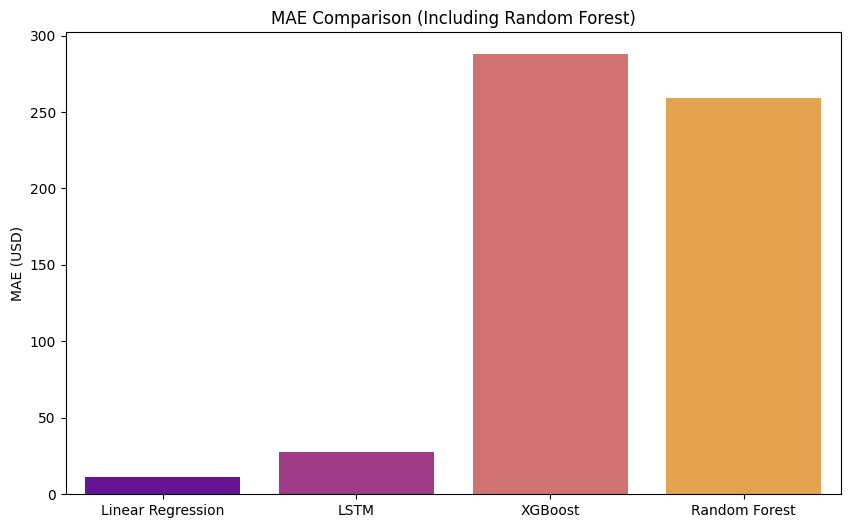

In [244]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Calculate metrics for Random Forest
rf_mse = mean_squared_error(y_test, rf_predictions)
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_r2 = r2_score(y_test, rf_predictions)
rf_mape_val = mape(y_test.values.flatten(), rf_predictions.flatten())

print("--- Model: Random Forest ---")
print(f"MSE:  {rf_mse:,.4f}")
print(f"MAE:  ${rf_mae:.2f}")
print(f"R2:   {rf_r2:.4f}")
print(f"MAPE: {rf_mape_val:.2f}%")

all_models = ['Linear Regression', 'LSTM', 'XGBoost', 'Random Forest']
all_maes = [lr_mae, lstm_mae, xgb_mae, rf_mae]

plt.figure(figsize=(10, 6))
sns.barplot(x=all_models, y=all_maes, hue=all_models, palette='plasma', legend=False)
plt.title('MAE Comparison (Including Random Forest)')
plt.ylabel('MAE (USD)')
plt.show()

### Prophet Model Training
Prophet requires a specific format: a DataFrame with columns `ds` (date) and `y` (value).

In [238]:
from prophet import Prophet


df_prophet = df.reset_index()[['Date', 'Close', 'Lag_1', 'MA_7', 'Volatility']].rename(columns={'Date': 'ds', 'Close': 'y'})

# Split data
train_prophet = df_prophet.iloc[:train_size]
test_prophet = df_prophet.iloc[train_size:]

# Initialize Prophet with tuned seasonality
m = Prophet(
    daily_seasonality=False,
    weekly_seasonality=True,
    yearly_seasonality=True,
    changepoint_prior_scale=0.05
)


m.add_regressor('Lag_1')
m.add_regressor('MA_7')
m.add_regressor('Volatility')


m.fit(train_prophet)


forecast = m.predict(test_prophet[['ds', 'Lag_1', 'MA_7', 'Volatility']])
prophet_predictions = forecast['yhat'].values

print("Improved Prophet model (with Regressors) trained successfully.")

Improved Prophet model (with Regressors) trained successfully.


--- Comparison Metrics (Last 1069 days) ---
Prophet MSE:  284.0962
Prophet MAE:  $12.47
Prophet R2:   0.9982
Prophet MAPE: 0.60%


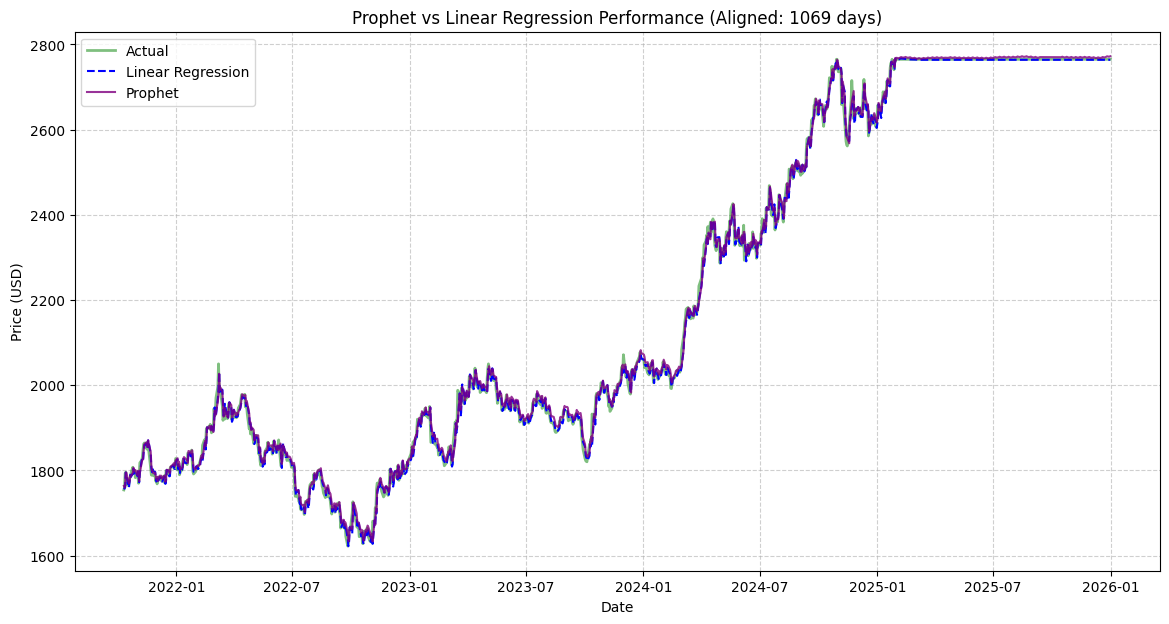

In [239]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import numpy as np


num_samples = 1069

y_test_subset = y_test.tail(num_samples)

dates_plot = y_test_subset.index.to_numpy()
actual_plot = y_test_subset.values.flatten()
lr_plot = predictions[-num_samples:].flatten()
prophet_plot = prophet_predictions[-num_samples:].flatten()

# 3. Calculate metrics for the aligned Prophet segment
prophet_mse = mean_squared_error(actual_plot, prophet_plot)
prophet_mae = mean_absolute_error(actual_plot, prophet_plot)
prophet_r2 = r2_score(actual_plot, prophet_plot)
prophet_mape_val = np.mean(np.abs((actual_plot - prophet_plot) / actual_plot)) * 100

print(f"--- Comparison Metrics (Last {num_samples} days) ---")
print(f"Prophet MSE:  {prophet_mse:,.4f}")
print(f"Prophet MAE:  ${prophet_mae:.2f}")
print(f"Prophet R2:   {prophet_r2:.4f}")
print(f"Prophet MAPE: {prophet_mape_val:.2f}%")


plt.figure(figsize=(14, 7))
plt.plot(dates_plot, actual_plot, label='Actual', color='green', alpha=0.5, linewidth=2)
plt.plot(dates_plot, lr_plot, label='Linear Regression', linestyle='--', color='blue')
plt.plot(dates_plot, prophet_plot, label='Prophet', color='purple', alpha=0.8)
plt.title(f'Prophet vs Linear Regression Performance (Aligned: {num_samples} days)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [240]:

print("Last 10 rows of the dataframe:")
display(df.tail(10))

print("\nUnique values in 'Close' for the last 500 rows:")
print(df['Close'].tail(500).nunique())

Last 10 rows of the dataframe:


,Open,High,Low,Close,Volume,MA_7,MA_30,EMA_7,Lag_1,Lag_2,Lag_3,Lag_7,Return,Rolling_STD_7,Rolling_Max_7,Rolling_Min_7,Volatility
Date,,,,,,,,,,,,,,,,,
2025-12-17,2765.26625,2781.20875,2741.79625,2765.23125,982753,2765.23125,2765.23125,2765.23125,2765.23125,2765.23125,2765.23125,2765.23125,0.0,0.0,2765.23125,2765.23125,39.4125
2025-12-18,2765.26625,2781.20875,2741.79625,2765.23125,1264198,2765.23125,2765.23125,2765.23125,2765.23125,2765.23125,2765.23125,2765.23125,0.0,0.0,2765.23125,2765.23125,39.4125
2025-12-19,2765.26625,2781.20875,2741.79625,2765.23125,939798,2765.23125,2765.23125,2765.23125,2765.23125,2765.23125,2765.23125,2765.23125,0.0,0.0,2765.23125,2765.23125,39.4125
2025-12-22,2765.26625,2781.20875,2741.79625,2765.23125,701691,2765.23125,2765.23125,2765.23125,2765.23125,2765.23125,2765.23125,2765.23125,0.0,0.0,2765.23125,2765.23125,39.4125
2025-12-23,2765.26625,2781.20875,2741.79625,2765.23125,1199792,2765.23125,2765.23125,2765.23125,2765.23125,2765.23125,2765.23125,2765.23125,0.0,0.0,2765.23125,2765.23125,39.4125
2025-12-24,2765.26625,2781.20875,2741.79625,2765.23125,892249,2765.23125,2765.23125,2765.23125,2765.23125,2765.23125,2765.23125,2765.23125,0.0,0.0,2765.23125,2765.23125,39.4125
2025-12-26,2765.26625,2781.20875,2741.79625,2765.23125,700640,2765.23125,2765.23125,2765.23125,2765.23125,2765.23125,2765.23125,2765.23125,0.0,0.0,2765.23125,2765.23125,39.4125
2025-12-29,2765.26625,2781.20875,2741.79625,2765.23125,1087202,2765.23125,2765.23125,2765.23125,2765.23125,2765.23125,2765.23125,2765.23125,0.0,0.0,2765.23125,2765.23125,39.4125
2025-12-30,2765.26625,2781.20875,2741.79625,2765.23125,1401078,2765.23125,2765.23125,2765.23125,2765.23125,2765.23125,2765.23125,2765.23125,0.0,0.0,2765.23125,2765.23125,39.4125



Unique values in 'Close' for the last 500 rows:
281


### **Final Accuracy Report**
In regression, we use error metrics to define accuracy.
- **MAE**: Average error in USD.
- **MAPE**: Average percentage error (Accuracy = 100% - MAPE).
- **R² Score**: How much of the price variance is explained by the model.

In [260]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Using the aligned 1069-day test set
num_samples = 1069
y_true = y_test.tail(num_samples).values
y_pred = predictions[-num_samples:].flatten()

# Calculations
mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_true, y_pred)
mape_val = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
accuracy_pct = 100 - mape_val

print(f"--- Final Forecasting Accuracy (Linear Regression) ---")
print(f"Mean Absolute Error (MAE): ${mae:.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:.2f}")
print(f"R-squared (R2) Score: {r2:.4f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape_val:.2f}%")
print(f"Directional Accuracy (Percentage): {accuracy_pct:.2f}%")

--- Final Forecasting Accuracy (Linear Regression) ---
Mean Absolute Error (MAE): $12.88
Root Mean Squared Error (RMSE): $16.78
R-squared (R2) Score: 0.9982
Mean Absolute Percentage Error (MAPE): 0.60%
Directional Accuracy (Percentage): 99.40%
